# Proyecto 2  Análisis exploratorio y visualización de datos de EcoEnergy Solutions

Claudio Grondona

Comenzamos por la revisión del csv para comprobar el estado de los datos.

In [ ]:
import pandas as pd

df = pd.read_csv("ecoenergy-consumption-data.csv")

df.head(50)

,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.74,0.13,444.99,89
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.79,0.15,1157.10,37
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.34,0.14,524.30,69
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.05,0.18,1467.18,29
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.67,0.24,752.88,50
5,6,"Robinson, Mclaughlin and Mitchell",Norte,Comercial,8849,2024-04-27,1023.01,0.21,1858.29,8
6,7,Rios-Johnson,Centro,Residencial,2218,2024-03-01,317.11,0.21,465.78,10
7,8,"Robinson, Gutierrez and Daniels",Oeste,Residencial,5349,2024-05-10,558.01,0.13,695.37,29
8,9,Wallace Ltd,Este,Residencial,8663,2024-05-01,1595.44,0.15,1299.45,48
9,10,"Richardson, Jenkins and Boyd",Centro,Residencial,4058,2024-07-26,232.76,0.14,568.12,92


A continuación obtenemos información básica usando info y revisando duplicated


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   client_id                    10000 non-null  int64  
 1   client_name                  10000 non-null  object 
 2   region                       10000 non-null  object 
 3   contract_type                10000 non-null  object 
 4   consumption_kwh              10000 non-null  int64  
 5   billing_date                 10000 non-null  object 
 6   co2_emissions                10000 non-null  float64
 7   cost_per_kwh                 10000 non-null  float64
 8   total_cost                   10000 non-null  float64
 9   renewable_energy_percentage  10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [ ]:
df[df.duplicated()]

,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage


Hasta aquí tenemos un archivo bastante limpio.  Siguiendo los pasos básicos para cualquiér tipo de datos vemos que tiene las columnas indicadas, no tiene nulos ni tampoco duplicados.


In [ ]:
# Convertir la columna al formato de fecha oficial de Pandas
df["billing_date"] = pd.to_datetime(df["billing_date"])

# Verificar que el tipo de dato ha cambiado (debería mostrar datetime64[ns])
print(df["billing_date"].dtype)

datetime64[ns]


In [ ]:
df.describe()


,client_id,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
count,10000.00000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,5051.087500,2024-06-04 13:05:39.840000,1019.702840,0.174928,886.023571,49.113500
min,1.00000,100.000000,2024-01-01 00:00:00,50.040000,0.100000,10.000000,0.000000
25%,2500.75000,2588.000000,2024-03-20 00:00:00,536.412500,0.140000,418.455000,24.000000
50%,5000.50000,5032.500000,2024-06-04 00:00:00,1020.240000,0.180000,818.625000,49.000000
75%,7500.25000,7542.250000,2024-08-22 00:00:00,1510.840000,0.210000,1276.492500,74.000000
max,10000.00000,9999.000000,2024-11-08 00:00:00,1999.940000,0.250000,2497.500000,99.000000
std,2886.89568,2867.303781,NaN,563.427136,0.043951,565.830649,28.812154


No parece haber fallos en los datos proporcionados


In [ ]:
# Check data types for client_name column
unique_types = df["client_name"].apply(type).unique()
print(unique_types)

if len(unique_types) == 1 and unique_types[0] is str:
    print("Interpretation: All client names are of type string. This indicates good data consistency for this column.")
else:
    print(f"Interpretation: Client names contain mixed types: {unique_types}. This might indicate a data quality issue.")

[<class 'str'>]
Interpretation: All client names are of type string. This indicates good data consistency for this column.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   client_id                    10000 non-null  int64         
 1   client_name                  10000 non-null  object        
 2   region                       10000 non-null  object        
 3   contract_type                10000 non-null  object        
 4   consumption_kwh              10000 non-null  int64         
 5   billing_date                 10000 non-null  datetime64[ns]
 6   co2_emissions                10000 non-null  float64       
 7   cost_per_kwh                 10000 non-null  float64       
 8   total_cost                   10000 non-null  float64       
 9   renewable_energy_percentage  10000 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 781.4+ KB


In [ ]:
print(df["billing_date"].apply(type).unique())

[<class 'pandas._libs.tslibs.timestamps.Timestamp'>]


Tras asegurarme de que no  tenemos tipos de datos que puedan dar un error y que los que tenemos sean correctos cambiamos el formato de la hora. ( aqunque no será necesario)

# *ATENCIÓN*
El siguiente paso puede ser obviado.  Voy a autentificar mi cuenta de google para generar un archivo que guardaré en google Drive y más tarde compartiré con DataStudio.

In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
import google.auth
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

In [ ]:
sh = gc.create("Dataset_Looker_ecoenergy")
worksheet = sh.get_worksheet(0)

# Convert billing_date column to string to make it JSON serializable
df_to_export = df.copy()
df_to_export["billing_date"] = df_to_export["billing_date"].astype(str)

# Looker Studio necesita los encabezados en la primera fila, gspread lo maneja automáticamente
worksheet.update([df_to_export.columns.values.tolist()] + df_to_export.fillna("").values.tolist())
print(f"Archivo creado exitosamente. Puedes buscarlo en tu Google Drive como: {sh.title}")

Archivo creado exitosamente. Puedes buscarlo en tu Google Drive como: Dataset_Looker_ecoenergy


Vamos  a pasar a analizar patrones de consumo segun región y tipo de contrato.


Cruzando estas variables usando .groupby y .agg podemos ver algunas tendencias.

La región que más gasta es la norte en comparación con las demás, siendo la oeste la que menos.
Los contratos comerciales son más rentables que los residenciales.

In [ ]:
# Agrupación por región y tipo de contrato
segment_analysis = df.groupby(["region", "contract_type"]).agg(
    total_consumption=("consumption_kwh", "sum"),
    avg_consumption=("consumption_kwh", "mean"),
    total_emissions=("co2_emissions", "sum"),
    total_cost=("total_cost", "sum"),
    avg_renewable=("renewable_energy_percentage", "mean")
).reset_index()

# Ordenar para identificar los segmentos con mayor consumo
print(segment_analysis.sort_values(by="total_consumption", ascending=False))

   region contract_type  total_consumption  avg_consumption  total_emissions  \
4   Norte     Comercial            5322882      5083.936963       1057788.49   
0  Centro     Comercial            5295884      5097.097209       1057759.28   
5   Norte   Residencial            5172514      5146.780100       1047729.98   
8     Sur     Comercial            5148668      5018.194932       1059694.96   
2    Este     Comercial            5140586      5120.105578        996489.27   
9     Sur   Residencial            5055822      5138.030488        989763.72   
1  Centro   Residencial            4959892      4954.937063       1006221.41   
3    Este   Residencial            4914454      4909.544456       1032443.16   
6   Oeste     Comercial            4791420      4904.216991        998854.60   
7   Oeste   Residencial            4708753      5140.560044        950283.53   

   total_cost  avg_renewable  
4   938069.65      49.647564  
0   936236.78      50.636189  
5   901555.81      49.4417

Vamos a ver si existe correlación entre variables.

Como es fácil de entender, podemos ver que si se consume más, el costo por kwh sube un poco, pero sobre todo el coste total.

Pero me llama la atención algo que no tiene sentido.

A más consumo de energía, más emisiones de CO₂. Aquí la correlación es cero. Esto significa que hay clientes que consumen muchísimo y no emiten nada...

In [ ]:
# Seleccionar solo las variables numéricas clave
numeric_cols = ["consumption_kwh", "co2_emissions", "cost_per_kwh", "total_cost", "renewable_energy_percentage"]
correlation_matrix = df[numeric_cols].corr()

# Mostrar la matriz en texto
print("Matriz de Correlación:")
print(correlation_matrix)

Matriz de Correlación:
                             consumption_kwh  co2_emissions  cost_per_kwh  \
consumption_kwh                     1.000000      -0.006932      0.019419   
co2_emissions                      -0.006932       1.000000     -0.006014   
cost_per_kwh                        0.019419      -0.006014      1.000000   
total_cost                          0.893300      -0.009146      0.408394   
renewable_energy_percentage        -0.009679       0.001337      0.013929   

                             total_cost  renewable_energy_percentage  
consumption_kwh                0.893300                    -0.009679  
co2_emissions                 -0.009146                     0.001337  
cost_per_kwh                   0.408394                     0.013929  
total_cost                     1.000000                    -0.003568  
renewable_energy_percentage   -0.003568                     1.000000  


Voy a revisar mediante un gráfico de dispersión.

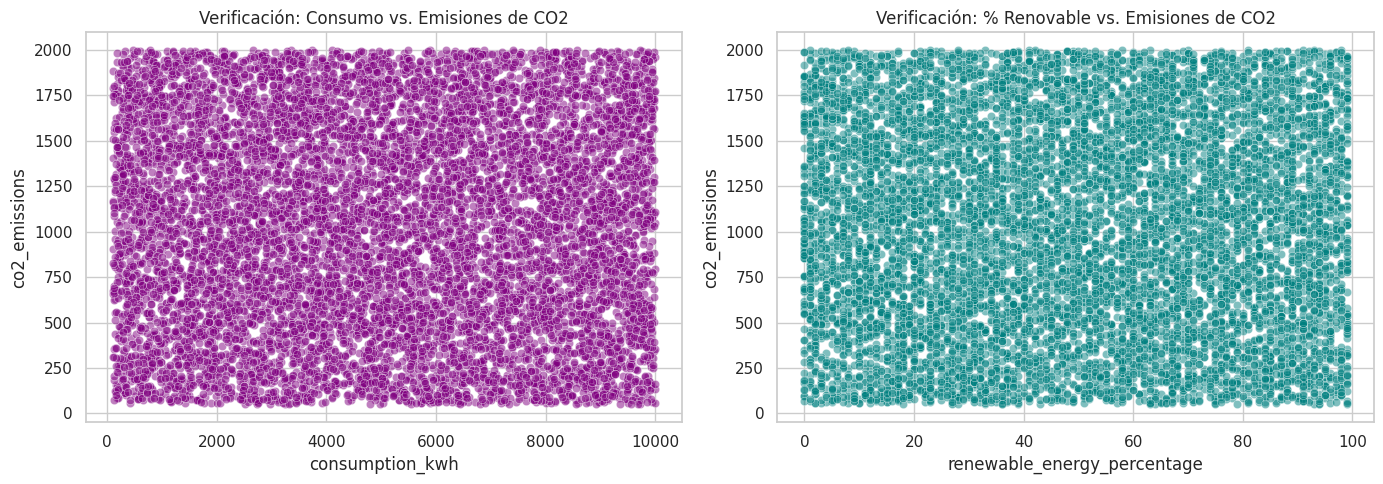

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Consumo vs CO2
sns.scatterplot(ax=axes[0], data=df, x="consumption_kwh", y="co2_emissions", alpha=0.5, color="purple")
axes[0].set_title("Verificación: Consumo vs. Emisiones de CO2")

# 2. Porcentaje Renovable vs CO2
sns.scatterplot(ax=axes[1], data=df, x="renewable_energy_percentage", y="co2_emissions", alpha=0.5, color="teal")
axes[1].set_title("Verificación: % Renovable vs. Emisiones de CO2")

plt.tight_layout()
plt.show()

Parece que los datos de prueba han sido generados aleatoriamente.

Nos aseguramos de que no hay outliers.

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Columna '{column}': Se detectaron {len(outliers)} valores atípicos fuera del rango ({lower_bound:.2f}, {upper_bound:.2f})")
    return outliers

# Probar la función con el consumo
consumo_outliers = detect_outliers_iqr(df, "consumption_kwh")

Columna 'consumption_kwh': Se detectaron 0 valores atípicos fuera del rango (-4843.38, 14973.62)


PAra ver de un vistazo los datos hacemos una cuadricula de graficos.


/tmp/ipykernel_9959/1227625228.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(temporal_trend["billing_month"], rotation=45)


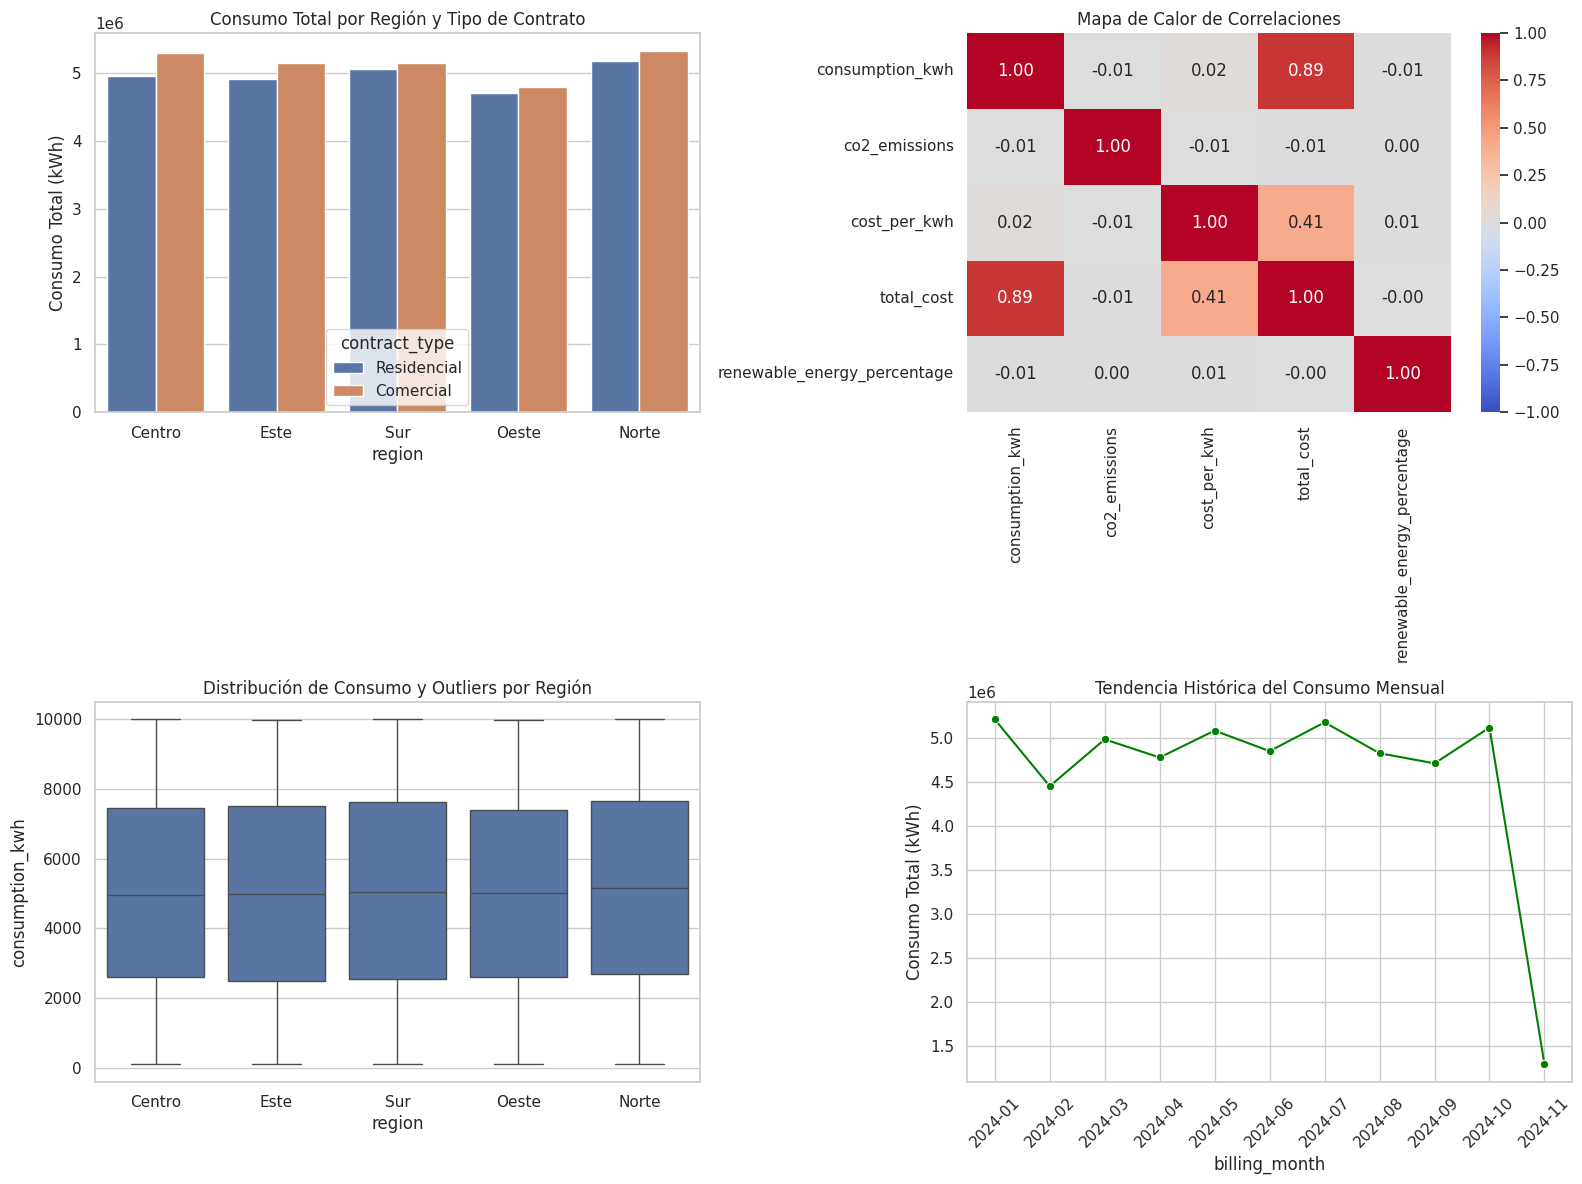

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



df["billing_month"] = df["billing_date"].dt.to_period("M")

temporal_trend = df.groupby("billing_month").agg(
    total_consumption=("consumption_kwh", "sum"),
    total_emissions=("co2_emissions", "sum"),
    total_cost=("total_cost", "sum")
).reset_index()

# Convertimos a texto para que matplotlib

temporal_trend["billing_month"] = temporal_trend["billing_month"].astype(str)




sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparación entre segmentos
sns.barplot(ax=axes[0,0], data=df, x="region", y="consumption_kwh", hue="contract_type", estimator=sum, errorbar=None)
axes[0,0].set_title("Consumo Total por Región y Tipo de Contrato")
axes[0,0].set_ylabel("Consumo Total (kWh)")

# 2. Mapa de calor de correlaciones
sns.heatmap(ax=axes[0,1], data=correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
axes[0,1].set_title("Mapa de Calor de Correlaciones")

# 3. Vista de valores atípicos  Diagrama de caja para el consumo
sns.boxplot(ax=axes[1,0], data=df, x="region", y="consumption_kwh")
axes[1,0].set_title("Distribución de Consumo y Outliers por Región")

# 4. Gráfico de tendencias temporales  Evolución del consumo mensual

sns.lineplot(ax=axes[1,1], data=temporal_trend, x="billing_month", y="total_consumption", marker="o", color="green")
axes[1,1].set_title("Tendencia Histórica del Consumo Mensual")
axes[1,1].set_xticklabels(temporal_trend["billing_month"], rotation=45)
axes[1,1].set_ylabel("Consumo Total (kWh)")

plt.tight_layout()
plt.show()

### Deducciones

1. **Segmentación Comercial:** Los contratos comerciales superan en consumo a los residenciales en todas las zonas, destacando las regiones Centro y Norte como los principales activos de demanda energética.
2. **Dinámica de Costes:** La facturación final está ligada estrechamente a los kWh consumidos (correlación 0.89). No se detecta ninguna relación lineal entre el consumo y las métricas de sostenibilidad (CO₂ y % renovable).
3. **Ausencia de Outliers:** El consumo por cliente está acotado de manera uniforme entre 0 y 10,000 kWh en todas las regiones, presentando distribuciones simétricas y sin presencia de valores atípicos.
4. **Efecto de Datos Truncados:** Se identifica una anomalía temporal en noviembre de 2024 con una caída del ~70% del consumo total. Se determina que responde a un cierre incompleto del periodo de facturación en el dataset original.